In [1]:
import torch
import time
import datetime
import random
import numpy as np
import polars as pl
from scipy.sparse import csr_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
EPOCHS = 10
BATCH_SIZE = 100

In [3]:
torch.set_default_dtype(torch.float32)
if torch.mps.is_available():
    torch.set_default_device(0)
    print("Running on the GPU")
else:
    print("Running on the CPU")

Running on the GPU


[bood_id_map.csv](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/book_id_map.csv)
[user_id_map.csv](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/user_id_map.csv)
[goodreads_books.json.gz](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/goodreads_books.json.gz)
[goodreads_reviews_dedup.json.gz](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/goodreads_reviews_dedup.json.gz)
[goodreads_interactions.csv](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/goodreads_interactions.csv)
[goodreads_interactions_dedup.json.gz](https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/goodreads_interactions_dedup.json.gz)

In [4]:
# book_ids = pl.read_csv('./data/book_id_map.csv')
# user_ids = pl.read_csv('./data/user_id_map.csv')
# books = pl.read_ndjson('./data/goodreads_books.json')
# reviews = pl.read_ndjson('./data/goodreads_reviews_dedup.json')
# interactions = pl.read_csv('./data/goodreads_interactions.csv')
# interactions_dedup = pl.read_ndjson('./data/goodreads_interactions_dedup.json')

# book_ids.write_ipc('./data/book_id_map.feather')
# user_ids.write_ipc('./data/user_id_map.feather')
# books.write_ipc('./data/goodreads_books.feather')
# reviews.write_ipc('./data/goodreads_reviews_dedup.feather')
# interactions.write_ipc('./data/goodreads_interactions.feather')
# interactions_dedup.write_ipc('./data/goodreads_interactions_dedup.feather')

In [5]:
book_ids = pl.read_ipc('./data/book_id_map.feather')
user_ids = pl.read_ipc('./data/user_id_map.feather')
books = pl.read_ipc('./data/goodreads_books.feather')
reviews = pl.read_ipc('./data/goodreads_reviews_dedup.feather')
interactions = pl.read_ipc('./data/goodreads_interactions.feather')
# interactions_dedup = pl.read_ipc('./data/goodreads_interactions_dedup.feather')

In [6]:
books.head()

isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
str,str,list[str],str,str,list[struct[2]],str,str,str,str,list[str],str,str,str,list[struct[2]],str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""0312853122""","""1""",[],"""US""","""""","[{""3"",""to-read""}, {""1"",""p""}, … {""1"",""biography""}]","""""","""false""","""4.00""","""""",[],"""""","""Paperback""","""https://www.goodreads.com/book…","[{""604031"",""""}]","""St. Martin's Press""","""256""","""1""","""9780312853129""","""9""","""""","""1984""","""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""5333265""","""3""","""5400751""","""W.C. Fields: A Life on Film""","""W.C. Fields: A Life on Film"""
"""0743509986""","""6""",[],"""US""","""""","[{""2634"",""to-read""}, {""160"",""fiction""}, … {""2"",""general""}]","""""","""false""","""3.23""","""B000FC0PBC""","[""8709549"", ""17074050"", … ""307575""]","""Anita Diamant's international …","""Audio CD""","""https://www.goodreads.com/book…","[{""626222"",""""}]","""Simon & Schuster Audio""","""""","""1""","""9780743509985""","""10""","""Abridged""","""2001""","""https://www.goodreads.com/book…","""https://s.gr-assets.com/assets…","""1333909""","""10""","""1323437""","""Good Harbor""","""Good Harbor"""
"""""","""7""","[""189911""]","""US""","""eng""","[{""58"",""to-read""}, {""15"",""fantasy""}, … {""1"",""read-in-my-20s""}]","""B00071IKUY""","""false""","""4.03""","""""","[""19997"", ""828466"", … ""1597281""]","""Omnibus book club edition cont…","""Hardcover""","""https://www.goodreads.com/book…","[{""10333"",""""}]","""Nelson Doubleday, Inc.""","""600""","""""","""""","""""","""Book Club Edition""","""1987""","""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""7327624""","""140""","""8948723""","""The Unschooled Wizard (Sun Wol…","""The Unschooled Wizard (Sun Wol…"
"""0743294297""","""3282""",[],"""US""","""eng""","[{""7615"",""to-read""}, {""728"",""chick-lit""}, … {""6"",""bookworm-bitches""}]","""""","""false""","""3.49""","""B002ENBLOK""","[""6604176"", ""6054190"", … ""3134684""]","""Addie Downs and Valerie Adler …","""Hardcover""","""https://www.goodreads.com/book…","[{""9212"",""""}]","""Atria Books""","""368""","""14""","""9780743294294""","""7""","""""","""2009""","""https://www.goodreads.com/book…","""https://s.gr-assets.com/assets…","""6066819""","""51184""","""6243154""","""Best Friends Forever""","""Best Friends Forever"""
"""0850308712""","""5""",[],"""US""","""""","[{""32"",""to-read""}, {""3"",""runes""}, … {""1"",""magick-and-myth""}]","""""","""false""","""3.40""","""""",[],"""""","""""","""https://www.goodreads.com/book…","[{""149918"",""""}]","""""","""""","""""","""9780850308716""","""""","""""","""""","""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""287140""","""15""","""278577""","""Runic Astrology: Starcraft and…","""Runic Astrology: Starcraft and…"


In [7]:
print(len(set(books['language_code'])))
set(books['language_code'])

227


{'',
 '--',
 'Select...',
 'aar',
 'abk',
 'ace',
 'ach',
 'ada',
 'ady',
 'afa',
 'afr',
 'aka',
 'ale',
 'alg',
 'amh',
 'ang',
 'anp',
 'apa',
 'ara',
 'arg',
 'arp',
 'arw',
 'asm',
 'ast',
 'aus',
 'ava',
 'ave',
 'awa',
 'aze',
 'bam',
 'bas',
 'bat',
 'bel',
 'ben',
 'bik',
 'bos',
 'btk',
 'bug',
 'bul',
 'cat',
 'chb',
 'che',
 'chi',
 'chm',
 'chn',
 'chp',
 'chv',
 'cop',
 'cor',
 'crh',
 'cze',
 'dak',
 'dan',
 'dgr',
 'din',
 'div',
 'dua',
 'dum',
 'dut',
 'dyu',
 'egy',
 'elx',
 'en',
 'en-CA',
 'en-GB',
 'en-IN',
 'en-US',
 'eng',
 'enm',
 'epo',
 'es-MX',
 'est',
 'eus',
 'fan',
 'fao',
 'fil',
 'fin',
 'fiu',
 'fre',
 'frm',
 'fro',
 'frs',
 'gem',
 'ger',
 'gez',
 'gla',
 'gle',
 'glg',
 'gmh',
 'grc',
 'gre',
 'grn',
 'gsw',
 'guj',
 'hat',
 'haw',
 'heb',
 'her',
 'hin',
 'hmn',
 'hun',
 'hye',
 'iba',
 'iku',
 'ilo',
 'ina',
 'ind',
 'ine',
 'inh',
 'ira',
 'iro',
 'isl',
 'ita',
 'jav',
 'jbo',
 'jpn',
 'jrb',
 'kal',
 'kam',
 'kan',
 'kat',
 'kau',
 'kaz',
 'khm

- ~~('isbn', String)~~
- ('text_reviews_count', String) -> Integer
- ~~('series', List(String))~~
- ('country_code', String) -> Boolean
- ('language_code', String) -> One Hot Encoding
- ~~('popular_shelves', List(Struct({'count': String, 'name': String})))~~
- ~~('asin', String)~~
- ('is_ebook', String) -> Boolean
- ('average_rating', String) -> Float
- ~~('kindle_asin', String)~~
- ~~('similar_books', List(String))~~
- ~~('description', String)~~
- ('format', String) -> One Hot Encoding
- ~~('link', String)~~
- ~~('authors', List(Struct({'author_id': String, 'role': String})))~~
- ~~('publisher', String)~~
- ('num_pages', String) -> Integer / Float
- ~~('publication_day', String)~~
- ~~('isbn13', String)~~
- ~~('publication_month', String)~~
- ~~('edition_information', String)~~
- ('publication_year', String) -> Integer / Float
- ~~('url', String)~~
- ~~('image_url', String)~~
- ~~('book_id', String)~~
- ('ratings_count', String) -> Integer / Float
- ~~('work_id', String)~~
- ~~('title', String)~~
- ~~('title_without_series', String)~~

In [8]:
books.drop_in_place('isbn')
books.drop_in_place('series')
books.drop_in_place('popular_shelves')
books.drop_in_place('asin')
books.drop_in_place('kindle_asin')
books.drop_in_place('similar_books')
books.drop_in_place('description')
books.drop_in_place('link')
books.drop_in_place('authors')
books.drop_in_place('publisher')
books.drop_in_place('isbn13')
books.drop_in_place('edition_information')
books.drop_in_place('url')
books.drop_in_place('image_url')
books.drop_in_place('work_id')
books.drop_in_place('title')
books.drop_in_place('title_without_series')

title_without_series
str
"""W.C. Fields: A Life on Film"""
"""Good Harbor"""
"""The Unschooled Wizard (Sun Wol…"
"""Best Friends Forever"""
"""Runic Astrology: Starcraft and…"
…
"""This Sceptred Isle, Vol. 10: T…"
"""Sherlock Holmes and the July C…"
"""The Children's Classic Poetry …"


In [9]:
books = books.with_columns(
    pl.when(pl.col('format').str.to_lowercase().str.contains_any([
        'audio',
        'mp3',
        'dvd',
        'pod',
        'compact disc',
        'audible',
        'album',
        'vhs',
        'radio',
        'score',
        'cd'
    ])).then(pl.col('format').str.replace_all('.*', 'Audio')).otherwise(pl.col('format')).alias('format')
)
books = books.with_columns(
    pl.when(pl.col('format').str.to_lowercase().str.contains_any([
        'e book', 
        'ebook',
        'pdf', 
        'p.d.f', 
        'epub', 
        'e pub',
        'hard',
        'e-', 
        'electronic', 
        'http',
        'online',
        'on-line',
        'link',
        'digital',
        'app',
        'kindle',
        'blog',
        'ibook',
        'ipad',
        'iphone',
        'scribd',
        'nook',
        'internet',
        'html',
        'url',
        'ejournal',
        'advance',
        'fanfic',
        'fan-fic',
        'fan-fic',
        'interactiv',
        'wattpad',
        'video',
        'web'
    ])).then(pl.col('format').str.replace_all('.*', 'Digital Text')).otherwise(pl.col('format')).alias('format')
)
books = books.with_columns(
    pl.when(pl.col('format').str.to_lowercase().str.contains_any([
        'cover',
        'covver',
        'back',
        'print',
        'bolsillo',
        'box',
        'binder',
        'paper',
        'leather',
        'stitch',
        'library',
        'chap',
        'card',
        'pocket',
        'book',
        '\\dx\\d',
        '\\d x \\d',
        ' cm',
        '8.5',
        'broch',
        'pamph',
        'novel',
        'capa ',
        'tapa ',
        'copertina ',
        'livro ',
        'papel',
        'flexible',
        'bound'
    ])).then(pl.col('format').str.replace_all('.*', 'Print')).otherwise(pl.col('format')).alias('format')
)
books = books.with_columns(
    pl.when(pl.col('format').str.to_lowercase().str.contains_any([
        'illustrat',
        'comic',
        'comisc',
        'graphic',
        'art',
        'popup',
        'pop up',
        'pop-up',
        'tarot',
        'board',
        'zine',
        'comixology',
        'issue'
        ])).then(pl.col('format').str.replace_all('.*', 'Illustrated')).otherwise(pl.col('format')).alias('format')
)
books = books.with_columns(
    pl.when(pl.col('format').str.contains_any([
        'Audio',
        'Digital Text',
        'Print',
        'Illustrated'
        ])).then(pl.col('format')).otherwise(pl.col('format').str.replace('.*', 'Other')).alias('format')
)

In [10]:
books = books.with_columns(
    pl.when(pl.col('publication_year').str.len_chars().eq(0)).then(pl.col('publication_year').str.replace('', '-1')).otherwise(pl.col('publication_year')).alias('publication_year')
)
books = books.with_columns(
    pl.when(pl.col('publication_month').str.len_chars().eq(0)).then(pl.col('publication_month').str.replace('', '1')).otherwise(pl.col('publication_month')).alias('publication_month')
)
books = books.with_columns(
    pl.when(pl.col('publication_day').str.len_chars().eq(0)).then(pl.col('publication_day').str.replace('', '1')).otherwise(pl.col('publication_day')).alias('publication_day')
)

In [11]:
books = books.with_columns(pl.col('publication_year').cast(pl.Int64))
books = books.with_columns(pl.col('publication_month').cast(pl.Int64))
books = books.with_columns(pl.col('publication_day').cast(pl.Int64))

In [12]:
books = books.with_columns(
    pl.when(pl.col('publication_year').gt(2026)).then(pl.col('publication_year').sub(pl.col('publication_year')).add(1)).otherwise(pl.col('publication_year'))
)
books = books.with_columns(
    pl.when(pl.col('publication_month').gt(12)).then(pl.col('publication_month').sub(pl.col('publication_month')).add(1)).otherwise(pl.col('publication_month'))
)
books = books.with_columns(
    pl.when(pl.col('publication_day').gt(28)).then(pl.col('publication_day').sub(pl.col('publication_day')).add(1)).otherwise(pl.col('publication_day'))
)

In [13]:
books = books.with_columns(publication_date=(
                            pl.col('publication_year').cast(pl.String) + '-' + 
                            pl.col('publication_month').cast(pl.String) + '-' +
                            pl.col('publication_day').cast(pl.String)).str.to_date('%Y-%m-%d'))
books.drop_in_place('publication_year')
books.drop_in_place('publication_month')
books.drop_in_place('publication_day')
books.head()

text_reviews_count,country_code,language_code,is_ebook,average_rating,format,num_pages,book_id,ratings_count,publication_date
str,str,str,str,str,str,str,str,str,date
"""1""","""US""","""""","""false""","""4.00""","""Print""","""256""","""5333265""","""3""",1984-09-01
"""6""","""US""","""""","""false""","""3.23""","""Audio""","""""","""1333909""","""10""",2001-10-01
"""7""","""US""","""eng""","""false""","""4.03""","""Digital Text""","""600""","""7327624""","""140""",1987-01-01
"""3282""","""US""","""eng""","""false""","""3.49""","""Digital Text""","""368""","""6066819""","""51184""",2009-07-14
"""5""","""US""","""""","""false""","""3.40""","""Other""","""""","""287140""","""15""",-0001-01-01


In [14]:
books = books.with_columns(
    pl.when(pl.col('language_code').str.contains('--') | pl.col('language_code').str.contains('Select...')).then(pl.col('language_code').str.replace('--', '').str.replace('Select...', '')).otherwise(pl.col('language_code')).alias('language_code')
)

In [15]:
books = books.with_columns(
    pl.when(pl.col('text_reviews_count').str.len_chars().eq(0)).then(pl.col('text_reviews_count').replace('', '0')).otherwise(pl.col('text_reviews_count'))
)
books = books.with_columns(
    pl.when(pl.col('is_ebook').str.len_chars().eq(0)).then(pl.col('is_ebook').replace('', '0')).otherwise(pl.col('is_ebook').replace('true', '1').replace('false', '0'))
)
books = books.with_columns(
    pl.when(pl.col('average_rating').str.len_chars().eq(0)).then(pl.col('average_rating').replace('', '0')).otherwise(pl.col('average_rating'))
)
books = books.with_columns(
    pl.when(pl.col('num_pages').str.len_chars().eq(0)).then(pl.col('num_pages').replace('', '0')).otherwise(pl.col('num_pages'))
)
books = books.with_columns(
    pl.when(pl.col('ratings_count').str.len_chars().eq(0)).then(pl.col('ratings_count').replace('', '0')).otherwise(pl.col('ratings_count'))
)
books = books.with_columns(
    pl.when(pl.col('country_code').str.len_chars().eq(0)).then(pl.col('country_code').replace('', '0')).otherwise(pl.col('country_code').replace('US', '1'))
)

In [16]:
books = books.with_columns(pl.col('book_id').cast(pl.Int64))
books = books.with_columns(pl.col('text_reviews_count').cast(pl.Int64))
books = books.with_columns(pl.col('is_ebook').cast(pl.Int64))
books = books.with_columns(pl.col('average_rating').cast(pl.Float32))
books = books.with_columns(pl.col('num_pages').cast(pl.Int64))
books = books.with_columns(pl.col('ratings_count').cast(pl.Int64))
books = books.with_columns(pl.col('country_code').cast(pl.Int64))
books = books.to_dummies('language_code')
books = books.to_dummies('format')

In [17]:
interactions = interactions.filter(pl.col('is_read').eq(1))
interactions.drop_in_place('is_read')
interactions = interactions.filter(pl.col('user_id').is_duplicated())

In [18]:
book_ids.head()

book_id_csv,book_id
i64,i64
0,34684622
1,34536488
2,34017076
3,71730
4,30422361


In [19]:
user_ids.head()

user_id_csv,user_id
i64,str
0,"""8842281e1d1347389f2ab93d60773d…"
1,"""72fb0d0087d28c832f15776b0d9365…"
2,"""ab2923b738ea3082f5f3efcbbfacb2…"
3,"""d986f354a045ffb91234e4af4d1b12…"
4,"""7504b2aee1ecb5b2872d3da381c6c9…"


In [20]:
reviews.collect_schema()

Schema([('user_id', String),
        ('book_id', String),
        ('review_id', String),
        ('rating', Int64),
        ('review_text', String),
        ('date_added', String),
        ('date_updated', String),
        ('read_at', String),
        ('started_at', String),
        ('n_votes', Int64),
        ('n_comments', Int64)])

In [21]:
reviews.head()

user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
str,str,str,i64,str,str,str,str,str,i64,i64
"""8842281e1d1347389f2ab93d60773d…","""24375664""","""5cd416f3efc3f944fce4ce2db2290d…",5,"""Mind blowingly cool. Best scie…","""Fri Aug 25 13:55:02 -0700 2017""","""Mon Oct 09 08:55:59 -0700 2017""","""Sat Oct 07 00:00:00 -0700 2017""","""Sat Aug 26 00:00:00 -0700 2017""",16,0
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017""",28,1
"""8842281e1d1347389f2ab93d60773d…","""6392944""","""5e212a62bced17b4dbe41150e5bb90…",3,"""I haven't read a fun mystery b…","""Mon Jul 24 02:48:17 -0700 2017""","""Sun Jul 30 09:28:03 -0700 2017""","""Tue Jul 25 00:00:00 -0700 2017""","""Mon Jul 24 00:00:00 -0700 2017""",6,0
"""8842281e1d1347389f2ab93d60773d…","""22078596""","""fdd13cad0695656be99828cd75d6eb…",4,"""Fun, fast paced, and disturbin…","""Mon Jul 24 02:33:09 -0700 2017""","""Sun Jul 30 10:23:54 -0700 2017""","""Sun Jul 30 15:42:05 -0700 2017""","""Tue Jul 25 00:00:00 -0700 2017""",22,4
"""8842281e1d1347389f2ab93d60773d…","""6644782""","""bd0df91c9d918c0e433b9ab3a9a5c4…",4,"""A fun book that gives you a se…","""Mon Jul 24 02:28:14 -0700 2017""","""Thu Aug 24 00:07:20 -0700 2017""","""Sat Aug 05 00:00:00 -0700 2017""","""Sun Jul 30 00:00:00 -0700 2017""",8,0


In [22]:
book_ids = book_ids.with_columns(pl.col('book_id').cast(pl.String))
reviews = reviews.join(book_ids, on='book_id')
reviews = reviews.join(user_ids, on='user_id')
reviews.drop_in_place('book_id')
reviews.drop_in_place('user_id')
reviews.drop_in_place('review_id')
reviews = reviews.with_columns(pl.col('book_id_csv').alias('book_id'))
reviews = reviews.with_columns(pl.col('user_id_csv').alias('user_id'))
reviews.drop_in_place('book_id_csv')
reviews.drop_in_place('user_id_csv')

user_id_csv
i64
0
0
0
0
0
…
876142
876144
876144


In [23]:
reviews = reviews.with_columns(pl.col('review_text').str.len_chars().alias('review_num_chars'))

Sat Aug 26 00:00:00 -0700 2017

In [24]:
reviews['date_added']

date_added
str
"""Fri Aug 25 13:55:02 -0700 2017"""
"""Sun Jul 30 07:44:10 -0700 2017"""
"""Mon Jul 24 02:48:17 -0700 2017"""
"""Mon Jul 24 02:33:09 -0700 2017"""
"""Mon Jul 24 02:28:14 -0700 2017"""
…
"""Mon Jun 04 18:08:44 -0700 2012"""
"""Fri Aug 01 18:46:18 -0700 2014"""
"""Tue Aug 27 12:49:25 -0700 2013"""


In [25]:
reviews.filter(pl.col('date_added').str.len_chars().eq(0) | pl.col('date_updated').str.len_chars().eq(0))

rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments,book_id,user_id,review_num_chars
i64,str,str,str,str,str,i64,i64,i64,i64,u32


In [26]:
reviews = reviews.with_columns(pl.col('date_added').str.strptime(dtype=pl.Datetime, format='%a %b %d %X %z %Y', ambiguous='earliest'))
reviews = reviews.with_columns(pl.col('date_updated').str.strptime(dtype=pl.Datetime, format='%a %b %d %X %z %Y', ambiguous='earliest'))
reviews = reviews.with_columns((pl.col('date_updated') - pl.col('date_added')).dt.total_days().alias('days_to_review'))
reviews.drop_in_place('review_text')
reviews.drop_in_place('date_updated')
reviews.drop_in_place('read_at')
reviews.drop_in_place('started_at')
reviews.drop_in_place('rating')

rating
i64
5
5
3
4
4
…
4
5
3


In [27]:
reviews.head()

date_added,n_votes,n_comments,book_id,user_id,review_num_chars,days_to_review
"datetime[μs, UTC]",i64,i64,i64,i64,u32,i64
2017-08-25 20:55:02 UTC,16,0,14,0,968,44
2017-07-30 14:44:10 UTC,28,1,21,0,2086,30
2017-07-24 09:48:17 UTC,6,0,22,0,474,6
2017-07-24 09:33:09 UTC,22,4,23,0,962,6
2017-07-24 09:28:14 UTC,8,0,24,0,420,30


In [28]:
users = books.join(interactions, on='book_id')
users = users.join(reviews, on=['book_id', 'user_id'], how='left')
users = users.with_columns((pl.col('date_added') - pl.col('publication_date')).dt.total_days().alias('days_to_start'))
users.drop_in_place('date_added')
users.drop_in_place('publication_date')
users.drop_in_place('is_reviewed')
users = users.fill_null(0)

In [29]:
users.head()

text_reviews_count,country_code,language_code_,language_code_aar,language_code_abk,language_code_ace,language_code_ach,language_code_ada,language_code_ady,language_code_afa,language_code_afr,language_code_aka,language_code_ale,language_code_alg,language_code_amh,language_code_ang,language_code_anp,language_code_apa,language_code_ara,language_code_arg,language_code_arp,language_code_arw,language_code_asm,language_code_ast,language_code_aus,language_code_ava,language_code_ave,language_code_awa,language_code_aze,language_code_bam,language_code_bas,language_code_bat,language_code_bel,language_code_ben,language_code_bik,language_code_bos,language_code_btk,…,language_code_tlh,language_code_ton,language_code_tup,language_code_tur,language_code_tut,language_code_udm,language_code_uig,language_code_ukr,language_code_und,language_code_urd,language_code_uzb,language_code_vai,language_code_vec,language_code_vie,language_code_vls,language_code_wak,language_code_wel,language_code_yid,language_code_zap,language_code_zho,is_ebook,average_rating,format_Audio,format_Digital Text,format_Illustrated,format_Other,format_Print,num_pages,book_id,ratings_count,user_id,rating,n_votes,n_comments,review_num_chars,days_to_review,days_to_start
i64,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i64,f32,u8,u8,u8,u8,u8,i64,i64,i64,i64,i64,i64,i64,u32,i64,i64
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.73,0,0,0,0,1,250,947,27,0,5,46,3,519,3867,733273
10,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.3,0,0,0,0,1,400,943,40,0,5,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.21,0,0,0,0,1,0,942,21,0,5,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.71,0,0,0,0,1,58,941,7,0,5,0,0,0,0,0
56,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.6,0,0,0,0,1,336,938,811,0,5,4,3,70,3858,3263


In [30]:
len(users.columns)

244

In [31]:
# users.group_by('user_id').agg(pl.exclude('book_id').mean())
users = users.sample(fraction=0.02)
print(len(users))

888421


In [32]:
def normalize_ids(df: pl.DataFrame, id: str):
    uniq_ids = set(df[id].unique())
    ids_to_indices = { orig_id : new_id for new_id, orig_id in enumerate(uniq_ids) }
    new_ids = df.with_columns(pl.col(id).replace(ids_to_indices).cast(pl.Int64))
    indices_to_ids = { new_id : orig_id for orig_id, new_id in ids_to_indices.items()}
    return new_ids, indices_to_ids

In [33]:
# users, _ = normalize_ids(users, 'user_id')

# users_n_books = users['book_id'].n_unique()

In [34]:
gss = GroupShuffleSplit(n_splits=5)

users_train_idx, users_test_idx = next(gss.split(X=users, groups=users['user_id']))
users_train: pl.Dataframe = users[users_train_idx]
users_test:  pl.Dataframe = users[users_test_idx]

In [35]:
users_test = users_test.filter(pl.col('user_id').is_duplicated())

In [36]:
# users_train, users_train_map_id = normalize_ids(users_train, 'user_id')
# users_test,  users_test_map_id  = normalize_ids(users_test, 'user_id')

# users_train_csr = csr_matrix((users_train['rating'], (users_train['user_id'], users_train['book_id'])), shape=(users_train['user_id'].n_unique(), users_n_books))

In [37]:
print(len(users_train))

710592


In [38]:
users_test_seen,   users_test_unseen         = train_test_split(users_test, train_size=0.7, stratify=users_test['user_id'])

# users_test_seen,   users_test_seen_map_id    = normalize_ids(users_test_seen,   'user_id')
# users_test_unseen, users_test_unseen_map_id  = normalize_ids(users_test_unseen, 'user_id')

# users_test_seen_csr = csr_matrix((users_test_seen['rating'], (users_test_seen['user_id'], users_test_seen['book_id'])), shape=(users_test_seen['user_id'].n_unique(), users_n_books))

In [39]:
users_train = users_train.group_by('user_id')
users_train_preds = users_train.agg(pl.exclude('book_id').mean())
users_test_seen = users_test_seen.group_by('user_id').agg(pl.exclude('book_id').mean())
users_test_unseen = users_test_unseen.group_by('user_id').agg(pl.exclude('book_id').mean())

In [40]:
users_test_seen = users_test_seen.filter(pl.col('user_id').is_in(users_test_unseen['user_id'].implode()))

In [41]:
class Timer(object):
    def __init__(self, name=None, filename=None):
        self.name = name
        self.filename = filename

    def __enter__(self):
        self.tstart = time.time()

    def __exit__(self, type, value, traceback):
        message = 'Elapsed: %.2f seconds' % (time.time() - self.tstart)
        if self.name:
            message = '[%s] ' % self.name + message
        print(message)
        if self.filename:
            with open(self.filename,'a') as file:
                print(str(datetime.datetime.now())+": ",message,file=file)

In [42]:
# print(interactions['user_id'].n_unique())
# print(interactions_n_books)
# print(interactions_train_csr.nnz)

In [43]:
class AE(torch.nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.model = torch.nn.Sequential()
        self.model.append(torch.nn.Linear(242,121))
        self.model.append(torch.nn.ReLU())
        self.model.append(torch.nn.Linear(121,121))
        self.model.append(torch.nn.ReLU())
        self.model.append(torch.nn.Linear(121,242))
        
    def forward(self, x):
        return self.model(x)

In [44]:
#loader = torch.utils.data.DataLoader(dataset=interactions_train_csr.data, batch_size=BATCH_SIZE, shuffle=True)
auto_encoder = AE()
loss_function = torch.nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(auto_encoder.parameters(), lr=0.001, weight_decay=0.00000001)

In [45]:
training_loss = []
testing_loss = []

In [46]:
with Timer('Total time'):
    with Timer('Training time'):
        for epoch in range(EPOCHS):
            with Timer(f'Epoch {epoch} Time'):
                for name, data in users_train:
                    x = torch.Tensor.to(data.drop('user_id').drop('book_id').to_torch(dtype=pl.Float32), device=0)
                    y = torch.Tensor.to(users_train_preds.filter(pl.col('user_id').eq(name[0])).drop('user_id').to_torch(dtype=pl.Float32), device=0)
                    if x.shape[0] == 0:
                        print(f'x: {x.shape}')
                    if y.shape[0] == 0:
                        print(f'y: {y.shape}')
                    pred = auto_encoder(x).mean(dim=0, keepdim=True)
                    loss = loss_function(pred, y, torch.ones(242))

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    test_user = users_test_seen.sample(n=1)
                    x_test = torch.Tensor.to(test_user.drop('user_id').to_torch(dtype=pl.Float32), device=0)
                    y_test = torch.Tensor.to(users_test_unseen.filter(pl.col('user_id').eq(test_user['user_id'][0])).drop('user_id').to_torch(dtype=pl.Float32), device=0)
                    if x_test.shape[0] == 0:
                        print(f'tx: {x_test.shape}')
                    if y_test.shape[0] == 0:
                        print(f'ty: {y_test.shape}')
                    test_pred = auto_encoder(x_test).mean(dim=0, keepdim=True)
                    test_loss = loss_function(test_pred, y_test, torch.ones(242))
                    training_loss.append(loss.item())
                    testing_loss.append(loss.item())

[Epoch 0 Time] Elapsed: 5672.37 seconds
[Epoch 1 Time] Elapsed: 6.11 seconds
[Training time] Elapsed: 5678.48 seconds
[Total time] Elapsed: 5678.48 seconds


KeyboardInterrupt: 

<Axes: >

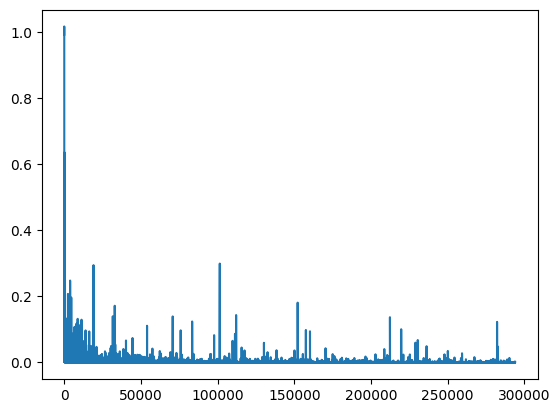

In [47]:
sns.lineplot(training_loss)

In [ ]:
sns.lineplot({'Train':training_loss, 'Test':testing_loss})

In [ ]:
print(testing_loss)